In [341]:
import sys
print(sys.executable)

/Users/adalenechan/IDXExchange Intern SU26/.venv/bin/python


Load Libraries

In [342]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load data
- The data exploration performed below concentrates on the data from June 2025 to May 2026.

In [343]:
files = [
    "data/CRMLSSold202506.csv",
    "data/CRMLSSold202507.csv",
    "data/CRMLSSold202508.csv",
    "data/CRMLSSold202509.csv",
    "data/CRMLSSold202510.csv",
    "data/CRMLSSold202511.csv",
    "data/CRMLSSold202512.csv",
    "data/CRMLSSold202601.csv",
    "data/CRMLSSold202602.csv",
    "data/CRMLSSold202603.csv",
    "data/CRMLSSold202604.csv",
    "data/CRMLSSold202605.csv",
]

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(df.shape)

/var/folders/tz/jmfckx6n1kb8sc7j2zzptcdm0000gn/T/ipykernel_29493/1493407157.py:16: DtypeWarning: Columns (0: WaterfrontYN) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
/var/folders/tz/jmfckx6n1kb8sc7j2zzptcdm0000gn/T/ipykernel_29493/1493407157.py:16: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


(258669, 78)


In [344]:
df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,SanDiego,SanDiego,NaN,False,NaN,NaN,False,5000.0,542181398,ops@downtowncondoguys.com,...,NaN,NaN,NaN,NaN,1.0,NaN,92101,0.0,NaN,NaN
1,PacificWest,PacificWest,NaN,True,NaN,NaN,NaN,110000.0,540760713,nowjoanne@gmail.com,...,NaN,355936.0,NaN,False,NaN,NaN,93550,0.0,355936.0,NaN
2,SouthwestLosAngeles,SouthwestLosAngeles,NaN,True,NaN,NaN,NaN,1545000.0,525608302,Austin_Brown@pacificplayarealty.com,...,88x231,20212.0,NaN,False,NaN,NaN,90008,NaN,20212.0,NaN
3,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,False,889000.0,523319952,hutton@cbappteam.com,...,NaN,9600.0,0.0,True,2.0,Rim of the World,92352,0.0,9600.0,NaN
4,SanDiego,SanDiego,Laminate,True,NaN,NaN,False,1700.0,518730969,mannybehar@yahoo.com,...,NaN,NaN,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN


Data Exploration

In [345]:
df["PropertyType"].value_counts()

PropertyType
Residential            173006
ResidentialLease        61076
Land                     7949
ResidentialIncome        7022
ManufacturedInPark       6642
CommercialSale           1588
CommercialLease          1242
BusinessOpportunity       144
Name: count, dtype: int64

In [346]:
df["PropertySubType"].value_counts()

PropertySubType
SingleFamilyResidence    158505
Condominium               44656
Townhouse                 14812
Apartment                  6722
Duplex                     5024
ManufacturedOnLand         2620
Triplex                    1694
Quadruplex                 1594
MixedUse                    880
StockCooperative            824
Office                      672
Retail                      424
Industrial                  277
Cabin                       242
Studio                      204
Business                    172
RoomingHouse                164
Warehouse                   136
MultiFamily                  67
SpecialPurpose               60
BoatSlip                     57
MobileHome                   48
OwnYourOwn                   38
Agriculture                  34
WaterPositionWithLand        33
Loft                         32
UnimprovedLand               27
ManufacturedHome             24
CoOwnership                   8
HotelMotel                    8
Timeshare               

The majority of property from 2025 june to 2026 may

Filter Dataset

In [347]:
df_restricted = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
]
df_restricted.shape


(130220, 78)

In [348]:
df_restricted.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
3,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,False,889000.0,523319952,hutton@cbappteam.com,...,NaN,9600.0,0.0,True,2.0,Rim of the World,92352,0.0,9600.0,NaN
10,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,True,NaN,NaN,False,1899999.0,1118606385,chase.campen@compass.com,...,26x100,10400.0,NaN,False,NaN,NaN,90046,NaN,10400.0,NaN
11,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1118606192,stanleylo@greenbanker.com,...,NaN,22505.0,NaN,False,3.0,Other,94010,NaN,22505.0,NaN
13,PacificWest,PacificWest,NaN,True,NaN,NaN,False,865000.0,1118604114,matt@majorleaguesocal.com,...,NaN,4800.0,3.0,False,2.0,Placentia-Yorba Linda Unified,92886,0.0,4800.0,NaN
14,BayEast,BayEast,"Carpet,Laminate",NaN,NaN,NaN,False,875000.0,1118603794,brianrowland.homes@gmail.com,...,NaN,5500.0,NaN,False,4.0,NaN,94546,NaN,5500.0,NaN


Summary statistics

In [349]:
selected_cols = df_restricted[
    ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]
]

selected_cols.describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,1.302200e+05,130152.000000,130220.000000,130208.000000,1.279840e+05
mean,1.345628e+06,2049.656470,3.494962,2.634016,3.888289e+05
std,8.260291e+06,1047.244954,0.963449,1.131053,1.803893e+07
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,6.250000e+05,1387.000000,3.000000,2.000000,5.663000e+03
50%,8.900000e+05,1820.000000,3.000000,2.000000,7.281000e+03
75%,1.415000e+06,2441.000000,4.000000,3.000000,1.045400e+04
max,9.895000e+08,56500.000000,22.000000,35.000000,1.938943e+09


In [350]:
# Examine appropriate bounds for ClosePrice
df_restricted["ClosePrice"].quantile([0, 0.1, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0])

0.00    0.000000e+00
0.10    4.420000e+05
0.25    6.250000e+05
0.50    8.900000e+05
0.75    1.415000e+06
0.95    3.163147e+06
0.99    6.400719e+06
1.00    9.895000e+08
Name: ClosePrice, dtype: float64

In [351]:
# Examine appropriate bounds for LivingArea
df_restricted["LivingArea"].quantile([0, 0.1, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0])

0.00        0.00
0.10     1104.00
0.25     1387.00
0.50     1820.00
0.75     2441.00
0.95     3825.45
0.99     5683.49
1.00    56500.00
Name: LivingArea, dtype: float64

In [352]:
# Examine appropriate bounds for LotSize
df_restricted["LotSizeSquareFeet"].quantile([0, 0.1, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0])

0.00    0.000000e+00
0.10    4.250000e+03
0.25    5.663000e+03
0.50    7.281000e+03
0.75    1.045400e+04
0.95    5.075000e+04
0.99    2.753731e+05
1.00    1.938943e+09
Name: LotSizeSquareFeet, dtype: float64

First, a subset of the dataframe is created to focus on observations with values within the range where the majority (~99%) lie for ClosePrice, LivingArea, and LotSize. The cut offs are determined using the quantile information obtained above to help improve readability of the dsitribution plots.

In [353]:
# Limit range of values for ClosePrice, LivingArea, and LotSizeSquareFeet
df_filtered = df_restricted[
    (df_restricted["ClosePrice"] > 10000) & (df_restricted["ClosePrice"] < 6500000) &
    (df_restricted["LivingArea"] < 10000) & (df_restricted["LotSizeSquareFeet"] < 150000)
]

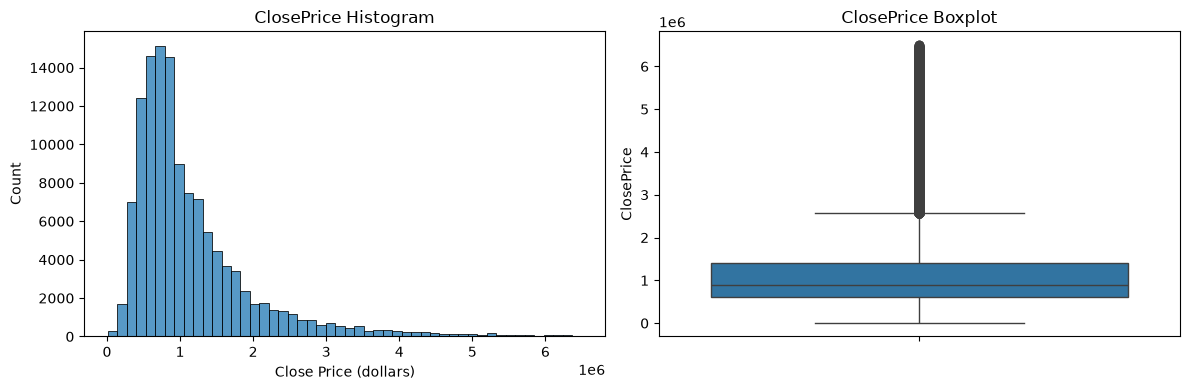

In [354]:
# ClosePrice
figs, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df_filtered, x="ClosePrice", bins=50, ax=axes[0])
axes[0].set_title("ClosePrice Histogram")
axes[0].set_xlabel("Close Price (dollars)")

sns.boxplot(df_filtered["ClosePrice"].dropna(), ax=axes[1])
axes[1].set_title("ClosePrice Boxplot")

plt.tight_layout()
plt.show()

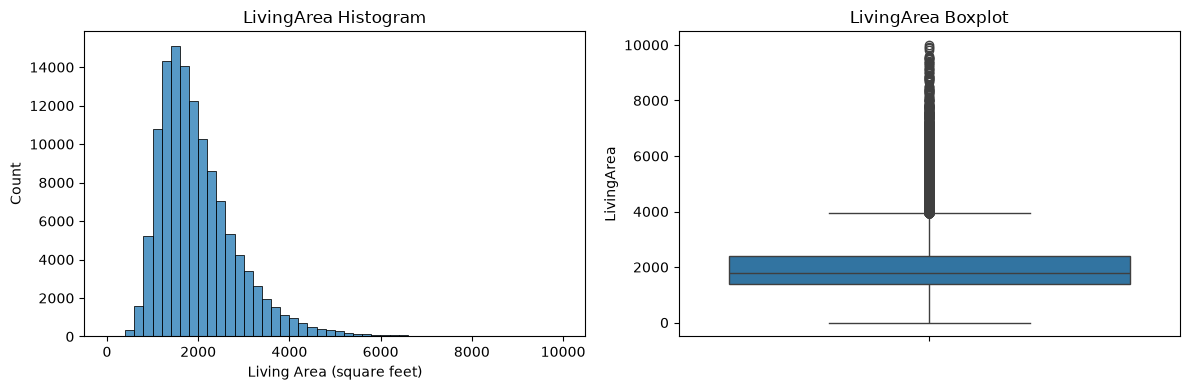

In [355]:
# LivingArea
figs, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_filtered["LivingArea"].dropna(), bins=50, ax=axes[0])
axes[0].set_title("LivingArea Histogram")
axes[0].set_xlabel("Living Area (square feet)")

sns.boxplot(df_filtered["LivingArea"].dropna(), ax=axes[1])
axes[1].set_title("LivingArea Boxplot")

plt.tight_layout()
plt.show()

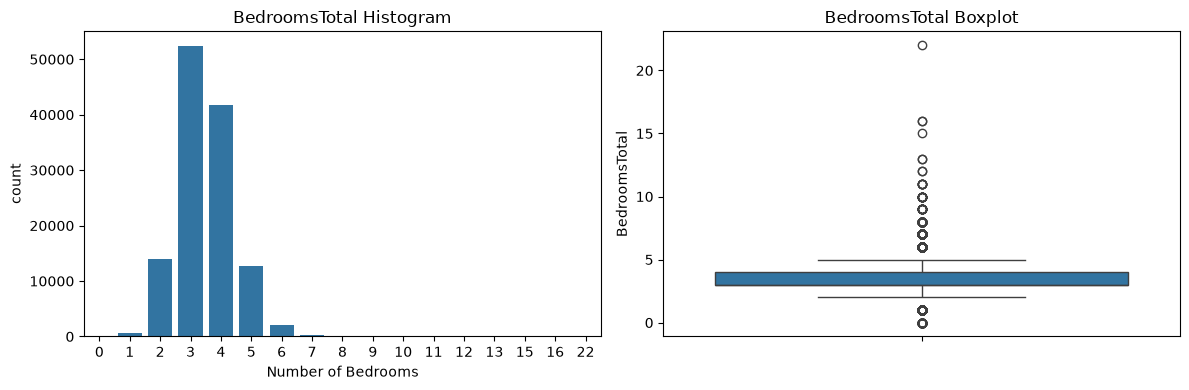

In [356]:
# Bedrooms
figs, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=df_filtered["BedroomsTotal"].dropna().astype(int), ax=axes[0])
axes[0].set_title("BedroomsTotal Histogram")
axes[0].set_xlabel("Number of Bedrooms")

sns.boxplot(df_filtered["BedroomsTotal"].dropna(), ax=axes[1])
axes[1].set_title("BedroomsTotal Boxplot")

plt.tight_layout()
plt.show()

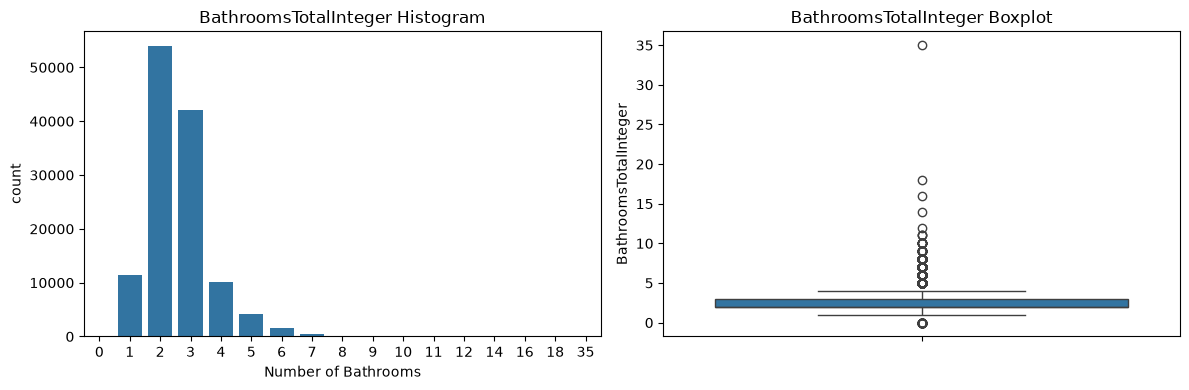

In [357]:
# Bathrooms
figs, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=df_filtered["BathroomsTotalInteger"].dropna().astype(int), ax=axes[0])
axes[0].set_title("BathroomsTotalInteger Histogram")
axes[0].set_xlabel("Number of Bathrooms")

sns.boxplot(df_filtered["BathroomsTotalInteger"].dropna(), ax=axes[1])
axes[1].set_title("BathroomsTotalInteger Boxplot")

plt.tight_layout()
plt.show()

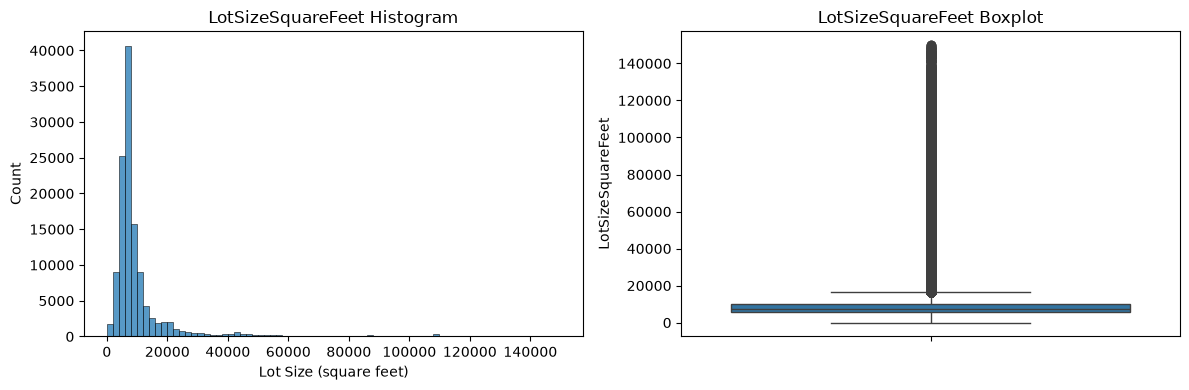

In [358]:
# LotSize
figs, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(x=df_filtered["LotSizeSquareFeet"].dropna(), bins=75, ax=axes[0])
axes[0].set_title("LotSizeSquareFeet Histogram")
axes[0].set_xlabel("Lot Size (square feet)")

sns.boxplot(df_filtered["LotSizeSquareFeet"].dropna(), ax=axes[1])
axes[1].set_title("LotSizeSquareFeet Boxplot")

plt.tight_layout()
plt.show()

Key Insights

All five variables appear right-skewed.
1. ClosePrice
    - Most properties were sold between 625K and 1415K, with a center at around 750K. 
    - There are also outliers that has close price well above 2.5M.
2. LivingArea
    - Most properties have a total livable area approximately between 1000 and 3000 square footage.
    - However, there are also outliers with a total livable area exceeding 4000 square footage, a threshold at which at least 95% of the observations lie below.
3. Bedrooms
    - Most properties have 2-5 bedrooms.
4. Bathrooms
    - Most properties have 1-5 bathrooms.
5. LotSize
    - Most properties have a total lot size of approxiamtely between 4K and 12K square footage.
    - There are also outliers with a total lot size well exceeding 20K square footage.